In [1]:
# from lcLevy.CRaw3. import*
from lcLevy.Image import Img
import skimage
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img = Img("EOS_R100/IMG_0004.CR3")

In [3]:
print(img.cr3)

{b'CNCV': b'CanonCR3_001/00.09.00/00.00.00', b'CTBO': {1: ctbo_line(index=1, offset=26168, size=65560), 2: ctbo_line(index=2, offset=91728, size=283976), 3: ctbo_line(index=3, offset=375704, size=33224880), 4: ctbo_line(index=4, offset=0, size=0), 5: ctbo_line(index=5, offset=0, size=0)}, b'CMT1': (320, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x000001E041EEA270>), b'CMT2': (712, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x000001E021D89310>), b'CMT3': (1840, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x000001E021D891D0>), b'CMT4': (7592, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x000001E041F25220>), b'THMB': (9408, thmb(w=160, h=120, size=14479)), 'trak1': {b'CRAW': craw(w=6000, h=4000, bits=24), b'stsz': [2156405], b'co64': [375720]}, 'trak2': {b'CMP1': cmp1(iw=1624, ih=1080, tw=1624, th=1080, d=14, p=4, cfa=1, extra=0, wl=0, b35=0, hsize=112), b'CRAW': craw(w=1624, h=1080, bits=24), b'stsz': [1637008], b'co64': [2532128]}, 'trak3': {b'CMP1': cmp1(iw=6288, ih=4056, tw=3144, th=4056, d=14, p=

In [3]:
crx = img.big_crx
# the stuff we have to play with
crx.display_tiles()
crx.display_planes()
crx.display_subbands()
# current plan is to figure out how to image all the components of these separately
# Then maybe put them together. 
# might be better to just go for the altogether first 

0 0x003f9e88 0x00df2f70
1 0x011ecdf8 0x00e136a8
0 0x003f9e88 0x00379278 0 1 0
0 0x00773100 0x00383cc0 1 1 0
0 0x00af6dc0 0x00383d48 2 1 0
0 0x00e7ab08 0x003722f0 3 1 0
1 0x011ecdf8 0x0037c418 0 1 0
1 0x01569210 0x003956c0 1 1 0
1 0x018fe8d0 0x003955f0 2 1 0
1 0x01c93ec0 0x0036c5e0 3 1 0
0 0 0 0x003f9e88 0x00379278 0 04 0
b'00000000002030230001803be273c6f3dbd8001d6a6883c0a776348fb727d21def4399189737122de5cbc2af665aa720b430215824a920b355fc5150214447b3'
0 1 0 0x00773100 0x00383cc0 0 04 4
b'00000000002030330000006363452bda2421e25241da84c244b5845a9f502b27a80000100431cb26cb22df5b2e3b3d1e6f56c6869975f3d3e234c0eec0284965'
0 2 0 0x00af6dc0 0x00383d48 0 04 4
b'0000000000202fb703000cb940b02ab938bce89e8568bf250d0f7a984cd3a0bf16d44b4bb5de03a1219a54a21246e50605edccb921447212222eabb025fe8a54'
0 3 0 0x00e7ab08 0x003722f0 0 04 7
b'000000000020300300002015f19e92c52b8dc4497eb1dc84e8b5210095134d9104f06ae481583ff07828cce517847605bf261de1d56c6dcc5ffadc987b64e299'
1 0 0 0x011ecdf8 0x0037c418 0 04 4
b'0000000

In [4]:
print(crx.subbands)
# print(planes)
# this guy has important stuff about image size
print(crx.cmp1)
print(crx.tiles)

{0: {0: {0: crx_subband(index=0, offset=4169352, size=3641976, supportsPartial=0, quantValue=4, val_19bits=0)}, 1: {0: crx_subband(index=0, offset=7811328, size=3685568, supportsPartial=0, quantValue=4, val_19bits=4)}, 2: {0: crx_subband(index=0, offset=11496896, size=3685704, supportsPartial=0, quantValue=4, val_19bits=4)}, 3: {0: crx_subband(index=0, offset=15182600, size=3613424, supportsPartial=0, quantValue=4, val_19bits=7)}}, 1: {0: {0: crx_subband(index=0, offset=18796024, size=3654680, supportsPartial=0, quantValue=4, val_19bits=4)}, 1: {0: crx_subband(index=0, offset=22450704, size=3757760, supportsPartial=0, quantValue=4, val_19bits=7)}, 2: {0: crx_subband(index=0, offset=26208464, size=3757552, supportsPartial=0, quantValue=4, val_19bits=3)}, 3: {0: crx_subband(index=0, offset=29966016, size=3589600, supportsPartial=0, quantValue=4, val_19bits=3)}}}
cmp1(iw=6288, ih=4056, tw=3144, th=4056, d=14, p=4, cfa=0, extra=0, wl=0, b35=0, hsize=216)
{0: crx_tile(index=0, offset=416935

In [5]:
# let's pull out some planes, why not!
data = crx.data
base = crx.base

# dictionary of planes and subbands
components = {
    "tiles": [crx.tiles[0], crx.tiles[1]],
    "planes": [crx.planes[0][i] for i in range(3)] + [crx.planes[1][i] for i in range(3)],
    "subbands": [crx.subbands[0][i][0] for i in range(3)] + [crx.subbands[1][i][0] for i in range(3)],
}

tiles = components["tiles"]
planes = components["planes"]
subb = components["subbands"]

def print_hex(bits):
    print(hex(int.from_bytes(bits)))

print_hex(data[tiles[0].offset-base-64:tiles[0].offset-base+64])
print_hex(data[planes[0].offset-base-46:planes[0].offset-base+64])
# print(planes)



# What actually goes on in the subbands?? who knows 
# may be good to check out the planes?



0x18000000ff030008003956c000200007ff020008003955f028000000ff030008003955f000200003ff0200080036c5e038000000ff0300080036c5e00020000300000000002030230001803be273c6f3dbd8001d6a6883c0a776348fb727d21def4399189737122de5cbc2af665aa720b430215824a920b355fc5150214447b3
0x8003955f028000000ff030008003955f000200003ff0200080036c5e038000000ff0300080036c5e00020000300000000002030230001803be273c6f3dbd8001d6a6883c0a776348fb727d21def4399189737122de5cbc2af665aa720b430215824a920b355fc5150214447b3


In [11]:
for sub in subb:
    print(sub.offset, sub.size)

4169352 3641976
7811328 3685568
11496896 3685704
18796024 3654680
22450704 3757760
26208464 3757552


In [6]:
real_img = skimage.io.imread("EOS_R100/IMG_0004.JPG")
real_img_arr = np.ndarray.flatten(real_img)

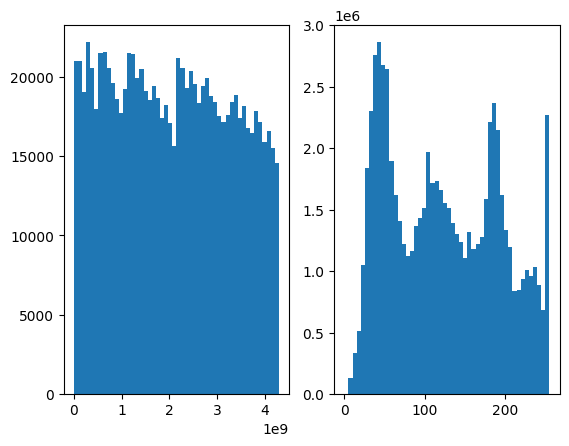

In [7]:
# make an array of pixel chunks from each subband
# histogram them, see if we can get them to match the original image brighntess distribution
pixel = 4
pixels = []

# for plane in planes[0]:
plane = subb[4]
for i in range(int(plane.size/pixel)):
    pixels.append(int.from_bytes(data[plane.offset-base+pixel*i:plane.offset-base+pixel*(i+1)]))
    # pixels.append(data[plane.offset-base+pixel*i:plane.offset-base+pixel*(i+1)])


fix, ax = plt.subplots(1,2)
ax[0].hist(pixels, bins = 50)

ax[1].hist(real_img_arr, bins = 50)
plt.show()



In [8]:
photo = []

chunk_size = 3
for j in range(4056):
    photo.append([])
    for i in range(6288):
        photo[j].append(int.from_bytes(data[start+chunk_size*i*j:start+chunk_size*(i*j+1)]))
plt.imshow(photo)


NameError: name 'start' is not defined

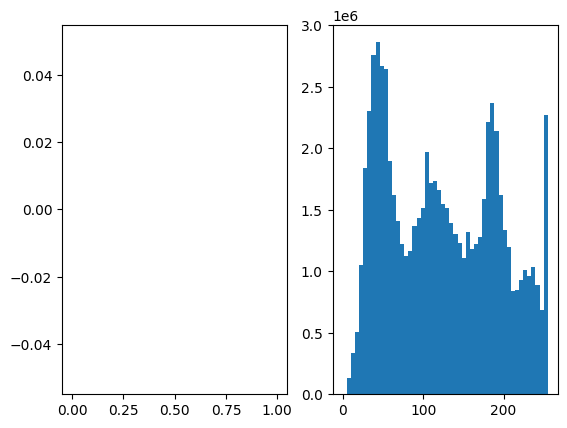

In [9]:
# Ideally these will be similar as we have a similar number of pixels at each brightness
# then again, maybe that's not what the subbands are for

# print(np.pow(2,63))
fix, ax = plt.subplots(1,2)
np_arr= np.array(photo)
ax[0].hist(np_arr.flatten(), bins = 50)

real_img = skimage.io.imread("EOS_R100/IMG_0004.JPG")
ax[1].hist(np.ndarray.flatten(real_img), bins = 50)
plt.show()

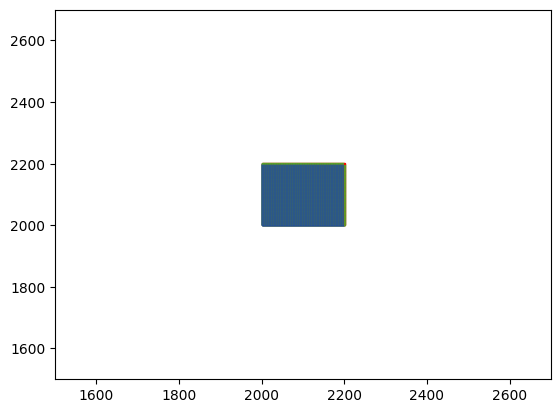

In [16]:
import matplotlib.patches as mpatches


def make_pix(color, x, y, size, brightness):
    return mpatches.Rectangle((x,y), size, size, color = color)

size = 1


# construct red plane???
red_dat = data[planes[0].offset-base: planes[0].offset-base+planes[0].size]
green_dat_one = data[planes[1].offset-base: planes[1].offset-base+planes[1].size]
green_dat_two = data[planes[2].offset-base: planes[2].offset-base+planes[2].size]
blue_dat = data[planes[3].offset-base: planes[3].offset-base+planes[3].size]
pix_width = 4

fig, ax = plt.subplots()
plt.xlim((1500,2700))
plt.ylim((1500,2700))

counter = 2000

for i in range(2000,2200):
    for j in range(2000,2200):
        ax.add_patch(make_pix("blue", i*size, j*size, size, blue_dat[counter*pix_width]))
        ax.add_patch(make_pix("limegreen", (i*size)+size,j*size, size, blue_dat[counter*pix_width]))
        ax.add_patch(make_pix("limegreen", i*size, (j*size)+size, size, blue_dat[counter*pix_width]))
        ax.add_patch(make_pix("red", (i*size)+size, (j*size)+size, size, red_dat[counter*pix_width]))
        counter += 1
         
            
    


plt.show()
